scenerio based questions:

1.sales analysis:

you need to create a sales data where the data should contains order date

you have monthly sales for 5 years

which plot will use to show the trends?

how will we compare sales across different regions?


2.Hr dataset

we want to check salary distribution by department

which plot you will use and why?

how to check the outliers in the dataset?

what is the importance of outliers and how it will impact on ml models?


3.health care dataset

cancer dataset

how many people affected with cancer?
gender(male/female)---cancer affecting gender

age(child/adult)---cancer affecting age group


4.banking dataset

you want to check correlation between the features

how will you vizualize correlation?

which plot should be use and why?

what is correlation?

how you can understand whether your data is strongly correlated or not

1.sales analysis:

you need to create a sales data where the data should contains order date

you have monthly sales for 5 years

which plot will use to show the trends?

how will we compare sales across different regions?

Best Plot for Trend → Line Plot

Because:

- Time-series data

- Shows growth / decline / seasonality

Best Plot for Region Comparison → Grouped Bar Chart

Because:

- Region = categorical

- Helps compare contributions

/tmp/ipython-input-1043/761715485.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2019-01-01', periods=60, freq='M')


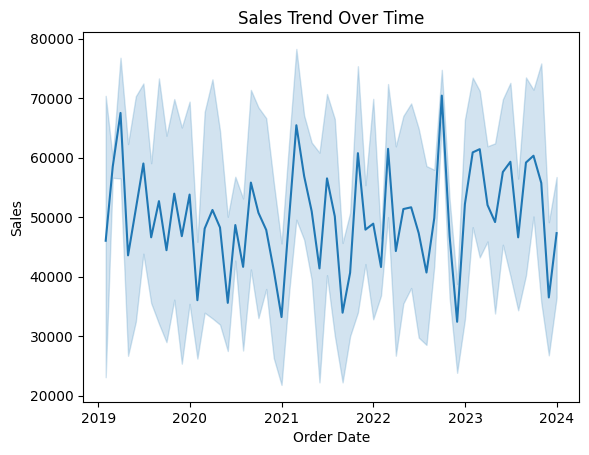

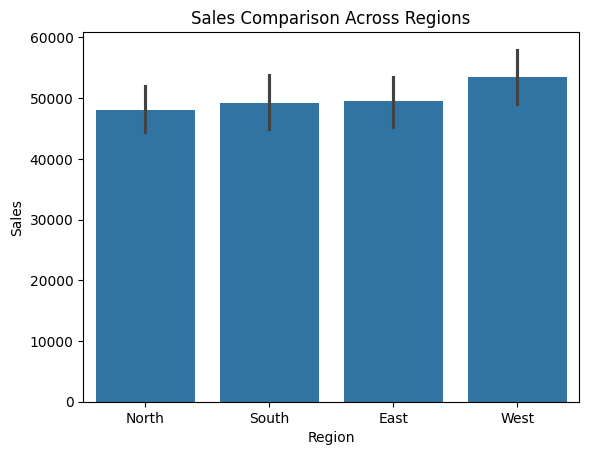

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create Date Range (5 years monthly)
dates = pd.date_range(start='2019-01-01', periods=60, freq='M')

regions = ['North', 'South', 'East', 'West']

data = pd.DataFrame({
    'Order Date': np.tile(dates, len(regions)),
    'Region': np.repeat(regions, len(dates)),
    'Sales': np.random.randint(20000, 80000, size=60*4)
})

# ----- Trend Line Plot -----
plt.figure()
sns.lineplot(data=data, x='Order Date', y='Sales')
plt.title("Sales Trend Over Time")
plt.show()

# ----- Region Comparison -----
plt.figure()
sns.barplot(data=data, x='Region', y='Sales')
plt.title("Sales Comparison Across Regions")
plt.show()

2.Hr dataset

we want to check salary distribution by department

which plot you will use and why?

how to check the outliers in the dataset?

Best Plot → Box Plot

Because:

Shows spread

Median

Variance

Outliers

Outlier Detection

Use:

- Boxplot
- IQR Method

Outliers impact ML:

- Skew regression

- Mislead clustering

- Reduce accuracy

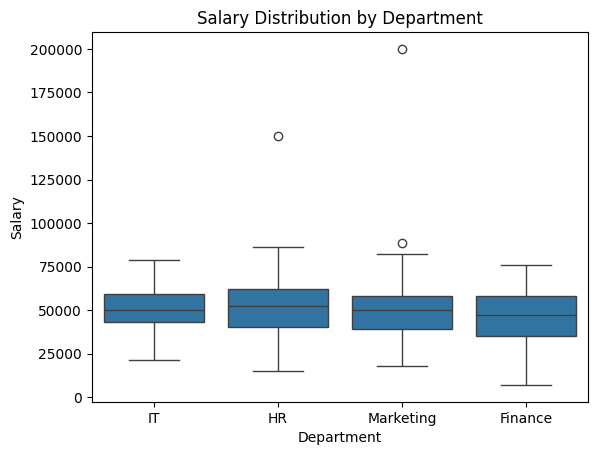

Outliers:
     Department         Salary
5           HR  150000.000000
10   Marketing  200000.000000
84     Finance    7108.248710
101  Marketing   88598.468251


In [2]:
departments = ['IT', 'HR', 'Finance', 'Marketing']

hr_data = pd.DataFrame({
    'Department': np.random.choice(departments, 200),
    'Salary': np.random.normal(50000, 15000, 200)
})

# Add Outliers
hr_data.loc[5, 'Salary'] = 150000
hr_data.loc[10, 'Salary'] = 200000

# ----- Salary Distribution -----
plt.figure()
sns.boxplot(data=hr_data, x='Department', y='Salary')
plt.title("Salary Distribution by Department")
plt.show()

# ----- IQR Outlier Detection -----
Q1 = hr_data['Salary'].quantile(0.25)
Q3 = hr_data['Salary'].quantile(0.75)
IQR = Q3 - Q1

outliers = hr_data[(hr_data['Salary'] < Q1 - 1.5*IQR) |
                   (hr_data['Salary'] > Q3 + 1.5*IQR)]

print("Outliers:\n", outliers)

3.health care dataset

cancer dataset

how many people affected with cancer?

gender(male/female)---cancer affecting gender

age(child/adult)---cancer affecting age group

| Question         | Plot        |
| ---------------- | ----------- |
| Total affected   | Countplot   |
| Gender impact    | Bar Plot    |
| Age group impact | Stacked Bar |


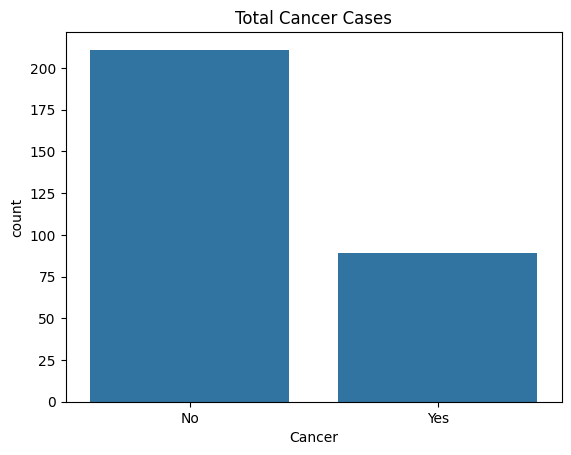

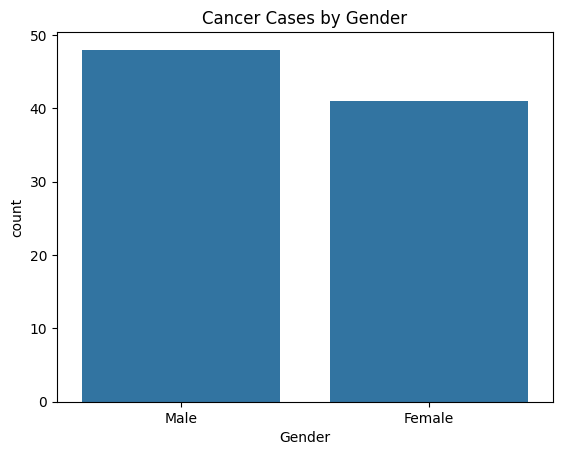

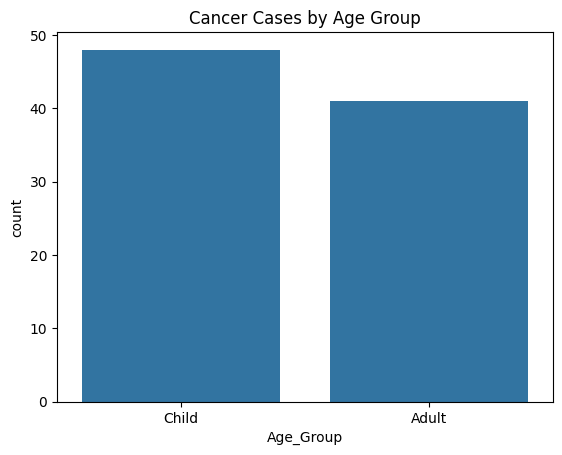

In [3]:
health_data = pd.DataFrame({
    'Gender': np.random.choice(['Male', 'Female'], 300),
    'Age_Group': np.random.choice(['Child', 'Adult'], 300),
    'Cancer': np.random.choice(['Yes', 'No'], 300, p=[0.3, 0.7])
})

# ----- Total Affected -----
plt.figure()
sns.countplot(data=health_data, x='Cancer')
plt.title("Total Cancer Cases")
plt.show()

# ----- Gender Impact -----
plt.figure()
sns.countplot(data=health_data[health_data['Cancer']=='Yes'], x='Gender')
plt.title("Cancer Cases by Gender")
plt.show()

# ----- Age Impact -----
plt.figure()
sns.countplot(data=health_data[health_data['Cancer']=='Yes'], x='Age_Group')
plt.title("Cancer Cases by Age Group")
plt.show()

4.banking dataset

you want to check correlation between the features

how will you vizualize correlation?

which plot should be use and why?

what is correlation?

how you can understand whether your data is strongly correlated or not

Best Plot → Heatmap

Because:

Shows multiple relationships at once

Easy to detect strong/weak correlation

What is Correlation?

Measures relationship between variables

| Value | Meaning         |
| ----- | --------------- |
| +1    | Strong Positive |
| 0     | No Relation     |
| -1    | Strong Negative |


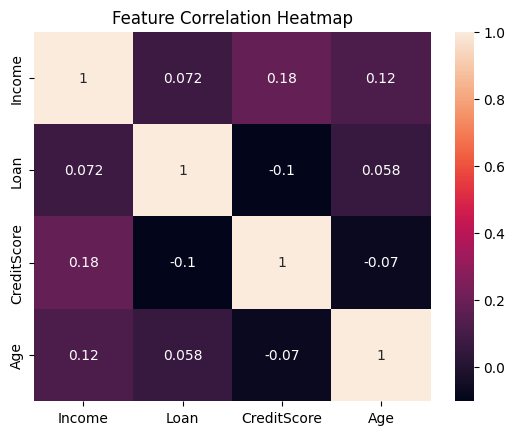

In [4]:
bank_data = pd.DataFrame({
    'Income': np.random.randint(20000, 100000, 200),
    'Loan': np.random.randint(5000, 50000, 200),
    'CreditScore': np.random.randint(300, 900, 200),
    'Age': np.random.randint(21, 65, 200)
})

corr = bank_data.corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()